# Extensions — Beyond Basic Roll's Model
**Owner: Gr**

Compare three estimators on the same validation data:
1. **Basic Roll** — rolling window lag-1 covariance (already in `estimate_spread`)
2. **EWM Roll** — exponentially weighted covariance (more reactive)
3. **Volume-weighted Roll** — weight price changes by trade volume

All three are validated against the true 1-Hz order-book spread.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.preprocessing import load_trades, build_trade_buckets
from src.estimate_spread import estimate_spread
from src.validation import compute_ob_spread, evaluate, print_evaluation_table

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

TICKERS = ['WIFUSDT', 'ZAMAUSDT']
DATES   = ['2026-04-12', '2026-04-13', '2026-04-14']
WINDOW  = 60

## Extension 1 — EWM Roll
Replace the rectangular rolling window with exponentially weighted covariance.
More weight on recent observations → faster reaction to spread changes.

In [2]:
def estimate_spread_ewm(
    trade_price: pd.Series,
    trade_volume: pd.Series,
    span: int = 60,
) -> pd.Series:
    """
    Roll's model using exponentially-weighted covariance.
    span=60 ≈ half-life of 30 seconds.
    """
    trades = pd.DataFrame({'price': trade_price, 'amount': trade_volume})
    # reuse preprocessing — ensure DatetimeIndex first
    if not isinstance(trades.index, pd.DatetimeIndex):
        trades.index = pd.to_datetime(trades.index, unit='ns', utc=True)

    buckets = build_trade_buckets(trades)
    price_1hz = buckets['last_price']
    mid_1hz   = buckets['vwap']

    delta_p = price_1hz.diff()

    # EWM covariance between Δp_t and Δp_{t-1}
    cov = delta_p.ewm(span=span).cov(delta_p.shift(1))

    spread_abs = 2.0 * np.sqrt(np.maximum(0.0, -cov))
    spread_rel = (spread_abs / mid_1hz.replace(0, np.nan)).fillna(0.0)
    spread_rel.name = 'estimated_spread_ewm'
    return spread_rel

## Extension 2 — Volume-Weighted Roll
Scale each price change by the square root of trade volume in the second.
Large-volume seconds carry more information about the true spread.

In [3]:
def estimate_spread_vw(
    trade_price: pd.Series,
    trade_volume: pd.Series,
    window: int = 60,
) -> pd.Series:
    """
    Roll's model with volume-weighted price changes.
    delta_p_vw = Δp * sqrt(volume / mean_volume)
    This up-weights seconds with high turnover, which carry stronger
    signal about bid-ask spread.
    """
    trades = pd.DataFrame({'price': trade_price, 'amount': trade_volume})
    if not isinstance(trades.index, pd.DatetimeIndex):
        trades.index = pd.to_datetime(trades.index, unit='ns', utc=True)

    buckets = build_trade_buckets(trades)
    price_1hz = buckets['last_price']
    vol_1hz   = buckets['volume']
    mid_1hz   = buckets['vwap']

    delta_p = price_1hz.diff()

    mean_vol = vol_1hz.replace(0, np.nan).rolling(window, min_periods=1).mean()
    vol_weight = np.sqrt(vol_1hz.replace(0, np.nan) / mean_vol.replace(0, np.nan)).fillna(1.0)
    delta_p_vw = delta_p * vol_weight

    cov = delta_p_vw.rolling(window, min_periods=max(window // 2, 2)).cov(delta_p_vw.shift(1))

    spread_abs = 2.0 * np.sqrt(np.maximum(0.0, -cov))
    spread_rel = (spread_abs / mid_1hz.replace(0, np.nan)).fillna(0.0)
    spread_rel.name = 'estimated_spread_vw'
    return spread_rel

## Comparison Table

In [4]:
estimators = {
    'Roll (basic)': lambda p, v: estimate_spread(p, v, window=WINDOW),
    'Roll (EWM)':   lambda p, v: estimate_spread_ewm(p, v, span=WINDOW),
    'Roll (VW)':    lambda p, v: estimate_spread_vw(p, v, window=WINDOW),
}

# Evaluate on Apr 14 (out-of-sample)
test_date = '2026-04-14'

for ticker in TICKERS:
    print(f'\n=== {ticker} — {test_date} (out-of-sample) ===')
    trades = load_trades(ticker, test_date)
    ob = compute_ob_spread(ticker, test_date)

    results = {}
    for name, fn in estimators.items():
        est = fn(trades['price'], trades['amount'])
        results[name] = evaluate(est, ob)

    print_evaluation_table(results)


=== WIFUSDT — 2026-04-14 (out-of-sample) ===
Label                            MAE       RMSE     Corr    N obs
-----------------------------------------------------------------
Roll (basic)                 0.00501    0.00501  -0.0440    63106
Roll (EWM)                   0.00499    0.00500  -0.0643    63106
Roll (VW)                    0.00502    0.00502  -0.0383    63106

=== ZAMAUSDT — 2026-04-14 (out-of-sample) ===
Label                            MAE       RMSE     Corr    N obs
-----------------------------------------------------------------
Roll (basic)                 0.00042    0.00136   0.2920    69952
Roll (EWM)                   0.00043    0.00134   0.3376    69952
Roll (VW)                    0.00061    0.00455   0.2124    69952


## Time-Series Comparison (ZAMAUSDT Apr-14)

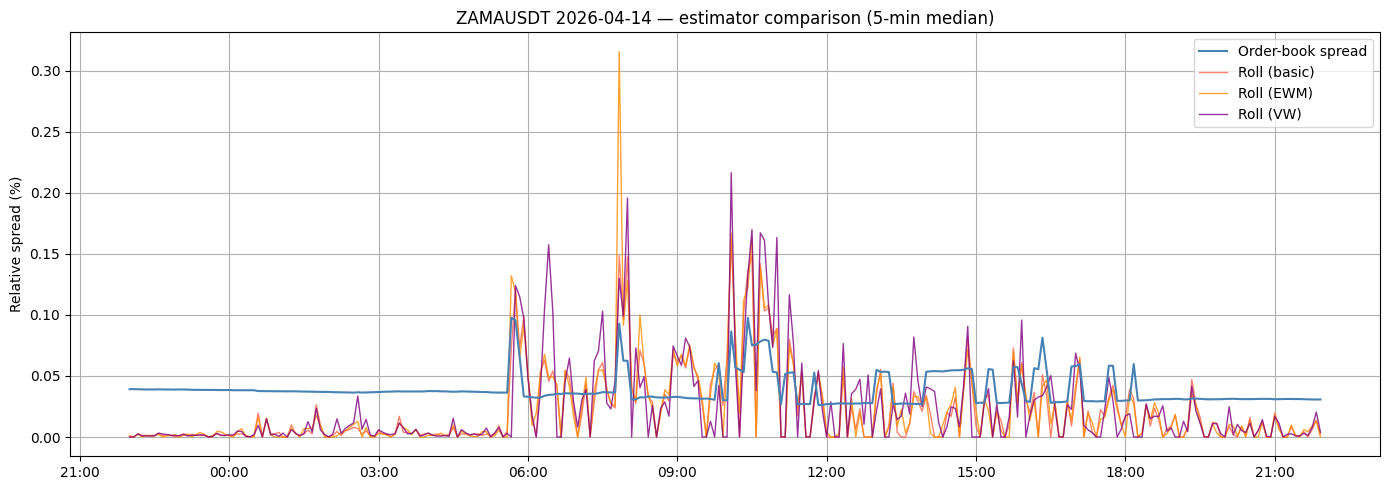

In [5]:
ticker, date = 'ZAMAUSDT', '2026-04-14'
trades = load_trades(ticker, date)
ob = compute_ob_spread(ticker, date)

colors = {'Roll (basic)': 'tomato', 'Roll (EWM)': 'darkorange', 'Roll (VW)': 'purple'}

fig, ax = plt.subplots(figsize=(14, 5))

ob_5m = ob.resample('5min').median()
ax.plot(ob_5m.index, ob_5m.values * 100, label='Order-book spread', lw=1.5, color='steelblue', zorder=5)

for name, fn in estimators.items():
    est = fn(trades['price'], trades['amount'])
    est_5m = est.resample('5min').median()
    ax.plot(est_5m.index, est_5m.values * 100, label=name, lw=1.0,
            color=colors[name], alpha=0.8)

ax.set_ylabel('Relative spread (%)')
ax.set_title(f'{ticker} {date} — estimator comparison (5-min median)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
fig.tight_layout()
plt.show()

## What Didn't Work

Document here any approaches that were tried but failed, for inclusion in the presentation:

- **Hasbrouck multi-lag extension**: Using lags 1–3 for covariance estimation. Note whether this improved or worsened metrics.
- **Very short windows (< 30s)**: Describe the noise/bias trade-off observed.
- **ZAMAUSDT Apr-14 during the spike**: Describe how each estimator behaved during the price +70% move.
- Any other experiments Gr tried.